In [1]:
import pandas as pd
import math
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Getting ground truth by measureing information across UE, real world, and camera algorithms

In [2]:
fire_gt = pd.read_csv('DataGroundTruth/FireDepth Experiment -- UE - FireLoc.csv')
camera_loc = pd.read_csv('DataGroundTruth/FireDepth Experiment -- UE - cameraLoc.csv')
fire_gt20 = pd.read_csv('DataGroundTruth/fireLoc_20_20.csv')

In [4]:
fire_loc = pd.read_csv('VideoAnalytics/scalability_exp_20_20/Detection_Results 2.csv')
cameras_numbers = []
fire_numbers = []
for row in fire_loc.image:
    cam_info = row.split('_')
    cam_num = cam_info[2].split('.')
    cameras_numbers.append(cam_num[0])
    fire_numbers.append(cam_info[0])
   
fire_loc.loc[:,["camera#"]] = cameras_numbers
fire_loc.loc[:,["Fire#"]] = fire_numbers

In [5]:
camera_video1_loc = camera_loc[camera_loc['Video#']==1]
cam8_loc=fire_loc[fire_loc['camera#']=='8']
cam1_loc=fire_loc[fire_loc['camera#']=='1']
cam11_loc=fire_loc[fire_loc['camera#']=='11']
cam4_loc=fire_loc[fire_loc['camera#']=='4']

# Fire Triangulation based on the same detected fire number with the hand crafted triangulation tactic

In [6]:
def triangulate_fireNum(fireNum):
    overlap_fire_footage = fire_loc[fire_loc['Fire#']==('Fire'+str(fireNum))]
    overlap_fire_footage
    angle_info = []
    for index, row  in overlap_fire_footage.iterrows():

        X_orientation = (row['xmin'] + row['xmax'])/2
        camera_info = camera_video1_loc[camera_video1_loc['camera#']==int(row['camera#'])]
        X_resolution = 1920
        hFOV = camera_info['hFOV']
        
        angle = (X_orientation - X_resolution/2)/X_resolution * hFOV
        angle_info.append([angle, int(camera_info['X_raster_loc']), int(camera_info['Y_raster_loc'])])

        
    numCams = len(angle_info)
    X_list = []
    Y_list = []
    for i in range(numCams):
        for j in range(i + 1, numCams):
            alpha_1, X_1, Y_1 = angle_info[i]
            alpha_2, X_2, Y_2 = angle_info[j]
            
            #alpha  = 270 + 15.136902760416667
            #beta = 1
            alpha_1 = math.radians(alpha_1)#
            alpha_2 = math.radians(alpha_2) #
            X_3 = ((Y_1 - Y_2) + X_2 * math.tan(alpha_2) - X_1 *math.tan(alpha_1))/ (math.tan(alpha_2) - math.tan(alpha_1))
            Y_3 = ((Y_1 * math.tan(alpha_2) - Y_2 * math.tan(alpha_1)) - ((X_1 - X_2) * math.tan(alpha_2) * math.tan(alpha_1)))/ (math.tan(alpha_2) - math.tan(alpha_1))
            X_list.append(X_3)
            Y_list.append(Y_3)
    X_average = sum(X_list) / len(X_list)
    Y_average = sum(Y_list) / len(Y_list)
    return X_average, Y_average

In [7]:
fire_combo = []
for i in range(400):
    if(len(fire_loc[fire_loc['Fire#']==('Fire'+str(i))]) > 1):
        fire_combo.append(i)

In [8]:
mono_heatmap_20_cross_cam = np.empty(shape=(20,20))
mono_heatmap_20_cross_cam.fill(500)

In [9]:
fire_len = len(fire_combo)
for num in range(fire_len):
    fireNum = fire_combo[num]
    fire_obj = fire_gt20[fire_gt20["Fire#"] == fireNum]
    #x_gt, y_gt = calc_cor(fire_obj['X'], fire_obj['Y'])
    
    #UE_X = fire_obj['X']
    #UE_Y = fire_obj['Y']
    
    gt_X = fire_obj['oriX']
    gt_Y = fire_obj['oriY']
    
    pred_X, pred_Y = triangulate_fireNum(fireNum)
    #gt_X, gt_Y = calc_cor(79050, 58650)
    diff_X = pred_X - gt_X
    diff_Y = pred_Y - gt_Y
    error = math.sqrt(diff_X * diff_X + diff_Y * diff_Y)
    error
    #print(num, error)
    
    # Find the location in the heatmap (which is geospatially a location in ground truth X from the origin).
    # The original location is measured by each fire center is 50 meters away.
    hm_X, hm_Y = int((gt_X-1000.0)/50), int((gt_Y-700.0)/50)
    mono_heatmap_20_cross_cam[hm_Y][hm_X] = error

/var/folders/g_/pxxlyt2j5vd7jmb4hwcv0rb40000gn/T/ipykernel_94386/4025365915.py:13: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  angle_info.append([angle, int(camera_info['X_raster_loc']), int(camera_info['Y_raster_loc'])])
/var/folders/g_/pxxlyt2j5vd7jmb4hwcv0rb40000gn/T/ipykernel_94386/4025365915.py:26: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  alpha_1 = math.radians(alpha_1)#
/var/folders/g_/pxxlyt2j5vd7jmb4hwcv0rb40000gn/T/ipykernel_94386/4025365915.py:27: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  alpha_2 = math.radians(alpha_2) #
/var/folders/g_/pxxlyt2j5vd7jmb4hwcv0rb40000gn/T/ipykernel_94386/2967678954.py:17: FutureWarning: Calling float on a single element Series is deprecated and w

# Data Visualization for Object-based Fire Triangulation

- The selected region is from 700, 1700 (in meters) in y (north-south) axis and 1000, 2000 in x (east-west) axis

In [10]:
X_vec = []
Y_vec = []
for Y in range(700, 1700, 50):
    if (Y + 100) % 200 == 0:
        Y_vec.append(Y)
    else:
        Y_vec.append('')
for X in range(1000, 2000, 50):
    
    if X % 200 == 0:
        X_vec.append(X)
    else:
        X_vec.append('')

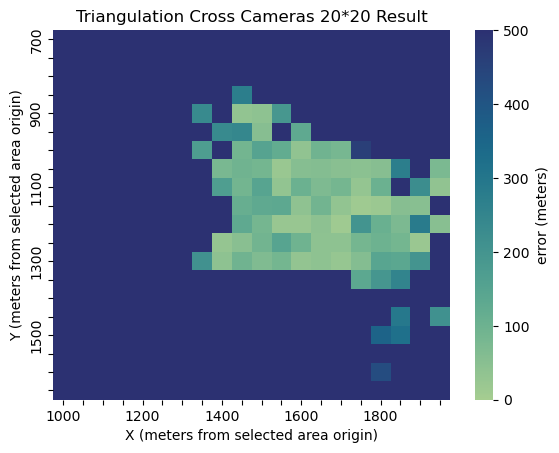

In [11]:
x_axis_labels = X_vec#[1450,1500, 1550, 1600, 1650] # labels for x-axis
y_axis_labels = Y_vec#[1000,1050,1100,1150,1200] # labels for y-axis
ax = sns.heatmap(mono_heatmap_20_cross_cam,xticklabels=x_axis_labels, yticklabels=y_axis_labels, vmin=0, vmax=500, cbar_kws={'label': 'error (meters)'}, cmap="crest")
plt.title('Triangulation Cross Cameras 20*20 Result')
plt.xlabel('X (meters from selected area origin)')
plt.ylabel('Y (meters from selected area origin)')
fig = ax.get_figure()
fig.savefig('VideoAnalytics/scalability_exp_20_20/heatmap1/crosscam_triangulation_result_20_20.png')
plt.show()